In [4]:
"""
Final Hybrid Model: ResNet-50 + CBAM + Vision Transformer
For Pneumothorax Detection with Enhanced Localization

Architecture:
- ResNet-50V2 backbone (frozen initially)
- CBAM attention for spatial/channel focus
- Vision Transformer for global context
- Binary classification with interpretability
"""

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 5e-4

# Transformer config
NUM_TRANSFORMER_BLOCKS = 6
HEAD_SIZE = 64
NUM_HEADS = 8
FF_DIM = 256
TRANSFORMER_DROPOUT = 0.1
PROJECTED_DIM = 512

# CBAM config
CBAM_RATIO = 8
CBAM_KERNEL_SIZE = 7

# Regularization
DROPOUT_RATE = 0
MLP_UNITS = [512]

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}")
print(f"  Attention Heads: {NUM_HEADS}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.0005
  Transformer Blocks: 6
  Attention Heads: 8


In [6]:
# ============================================================================
# LOAD BALANCED PNEUMOTHORAX DATASET
# ============================================================================

BASE_DIR = "../dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"\nLoading balanced Pneumothorax dataset...")
df = pd.read_csv(CSV_PATH)

# Use Binary_Label column
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)

# Create full image paths
df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify images exist
df['exists'] = df['path'].apply(os.path.exists)
df = df[df['exists']].copy().drop(columns=['exists'])

print(f"✓ Loaded {len(df):,} images")
print(f"  Pneumothorax: {df['binary_label'].sum():,} ({df['binary_label'].mean()*100:.1f}%)")
print(f"  Normal: {(~df['binary_label'].astype(bool)).sum():,}")



Loading balanced Pneumothorax dataset...
✓ Loaded 10,604 images
  Pneumothorax: 5,302 (50.0%)
  Normal: 5,302


In [7]:
# ============================================================================
# TRAIN/VAL SPLIT (80/20)
# ============================================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['binary_label']
)

print(f"\nDataset split:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val: {len(val_df):,} samples")


Dataset split:
  Train: 8,483 samples
  Val: 2,121 samples


In [ ]:
# ============================================================================
# CBAM ATTENTION MODULE
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        spatial_attention = self.conv(concat)
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super().get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'ratio': self.ratio,
            'kernel_size': self.kernel_size
        })
        return config

In [9]:
# ============================================================================
# VISION TRANSFORMER ENCODER
# ============================================================================

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Vision Transformer Encoder Block"""
    # Layer norm + Multi-head attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = layers.Add()([attention_output, inputs])
    
    # Feed-forward network
    ff_x = layers.LayerNormalization(epsilon=1e-6)(x)
    ff_x = layers.Dense(ff_dim, activation="gelu")(ff_x)
    ff_x = layers.Dropout(dropout)(ff_x)
    ff_x = layers.Dense(inputs.shape[-1])(ff_x)
    
    return layers.Add()([x, ff_x])

In [10]:
# ============================================================================
# HYBRID MODEL: ResNet-50 + CBAM + ViT
# ============================================================================

def create_hybrid_model(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=1,  # Binary classification
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    transformer_dropout=TRANSFORMER_DROPOUT,
    mlp_units=MLP_UNITS,
    dropout_rate=DROPOUT_RATE,
    projected_dim=PROJECTED_DIM,
    cbam_ratio=CBAM_RATIO,
    cbam_kernel_size=CBAM_KERNEL_SIZE
):
    """
    Hybrid architecture combining:
    - ResNet-50V2 for feature extraction
    - CBAM for attention-based feature refinement
    - Vision Transformer for global context
    """
    
    print("\nBuilding Hybrid Model...")
    
    # ResNet-50V2 backbone
    resnet_base = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    resnet_base.trainable = False  # Freeze initially
    
    inputs = layers.Input(shape=input_shape)
    
    # Stage 1: ResNet feature extraction
    x = resnet_base(inputs, training=False)
    print(f"  ResNet output shape: {x.shape}")
    
    # Stage 2: CBAM attention
    x = CBAM(ratio=cbam_ratio, kernel_size=cbam_kernel_size, name='cbam')(x)
    print(f"  CBAM applied (ratio={cbam_ratio}, kernel={cbam_kernel_size})")
    
    # Stage 3: Reshape for transformer
    _, h, w, c = x.shape
    patches = layers.Reshape((h * w, c))(x)
    print(f"  Reshaped to patches: {patches.shape}")
    
    # Project to transformer dimension
    x = layers.LayerNormalization(epsilon=1e-6)(patches)
    x = layers.Dense(projected_dim)(x)
    print(f"  Projected to {projected_dim} dims")
    
    # Stage 4: Transformer encoder blocks
    for i in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, transformer_dropout)
    print(f"  {num_transformer_blocks} Transformer blocks applied")
    
    # Stage 5: Global pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Stage 6: MLP head
    for dim in mlp_units:
        x = layers.Dense(dim, activation="gelu")(x)
        x = layers.Dropout(dropout_rate)(x)
    
    # Output
    outputs = layers.Dense(
        num_classes, 
        activation="sigmoid",
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )(x)
    
    model = keras.Model(inputs, outputs, name='Hybrid_ResNet_CBAM_ViT')
    
    print(f"\n✓ Model built successfully!")
    print(f"  Total params: {model.count_params():,}")
    
    return model, resnet_base


# Create model
model, base_model = create_hybrid_model()


Building Hybrid Model...
  ResNet output shape: (None, 7, 7, 2048)
  CBAM applied (ratio=8, kernel=7)
  Reshaped to patches: (None, 49, 2048)
  Projected to 512 dims
  6 Transformer blocks applied

✓ Model built successfully!
  Total params: 33,825,635


In [11]:
# ============================================================================
# TF.DATA PIPELINE
# ============================================================================

def create_tf_dataset(df, batch_size, shuffle=True, augment=True):
    """Create optimized tf.data pipeline"""
    
    def load_and_preprocess(image_path, label):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)
        
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, label
    
    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("\nCreating datasets...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✓ Datasets created")
print(f"  Train batches: {len(train_dataset)}")
print(f"  Val batches: {len(val_dataset)}")



Creating datasets...
✓ Datasets created
  Train batches: 266
  Val batches: 67


In [12]:
# ============================================================================
# COMPILATION
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n✓ Model compiled")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: binary_crossentropy")



✓ Model compiled
  Optimizer: Adam (lr=0.0005)
  Loss: binary_crossentropy


In [13]:
# ============================================================================
# CALLBACKS
# ============================================================================

os.makedirs('./output', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath='./output/pneumohybrid_model_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [14]:
# ============================================================================
# TRAINING
# ============================================================================

print("\n" + "="*80)
print("TRAINING HYBRID MODEL: ResNet-50 + CBAM + ViT")
print("="*80)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

model.save('./output/pneumohybrid_model_final.keras')
print("\n✓ Training complete! Model saved.")


TRAINING HYBRID MODEL: ResNet-50 + CBAM + ViT
Epoch 1/60
266/266 [==============================] - ETA: 0s - loss: 0.7010 - binary_accuracy: 0.6456 - auc: 0.6909 - precision: 0.6447 - recall: 0.6490
Epoch 1: val_auc improved from -inf to 0.78838, saving model to ./output\pneumohybrid_model_best.keras
266/266 [==============================] - 58s 152ms/step - loss: 0.7010 - binary_accuracy: 0.6456 - auc: 0.6909 - precision: 0.6447 - recall: 0.6490 - val_loss: 0.7684 - val_binary_accuracy: 0.6044 - val_auc: 0.7884 - val_precision: 0.5605 - val_recall: 0.9651 - lr: 5.0000e-04
Epoch 2/60
266/266 [==============================] - ETA: 0s - loss: 0.5973 - binary_accuracy: 0.7008 - auc: 0.7654 - precision: 0.6957 - recall: 0.7140
Epoch 2: val_auc did not improve from 0.78838
266/266 [==============================] - 38s 142ms/step - loss: 0.5973 - binary_accuracy: 0.7008 - auc: 0.7654 - precision: 0.6957 - recall: 0.7140 - val_loss: 0.5813 - val_binary_accuracy: 0.7129 - val_auc: 0.7829 

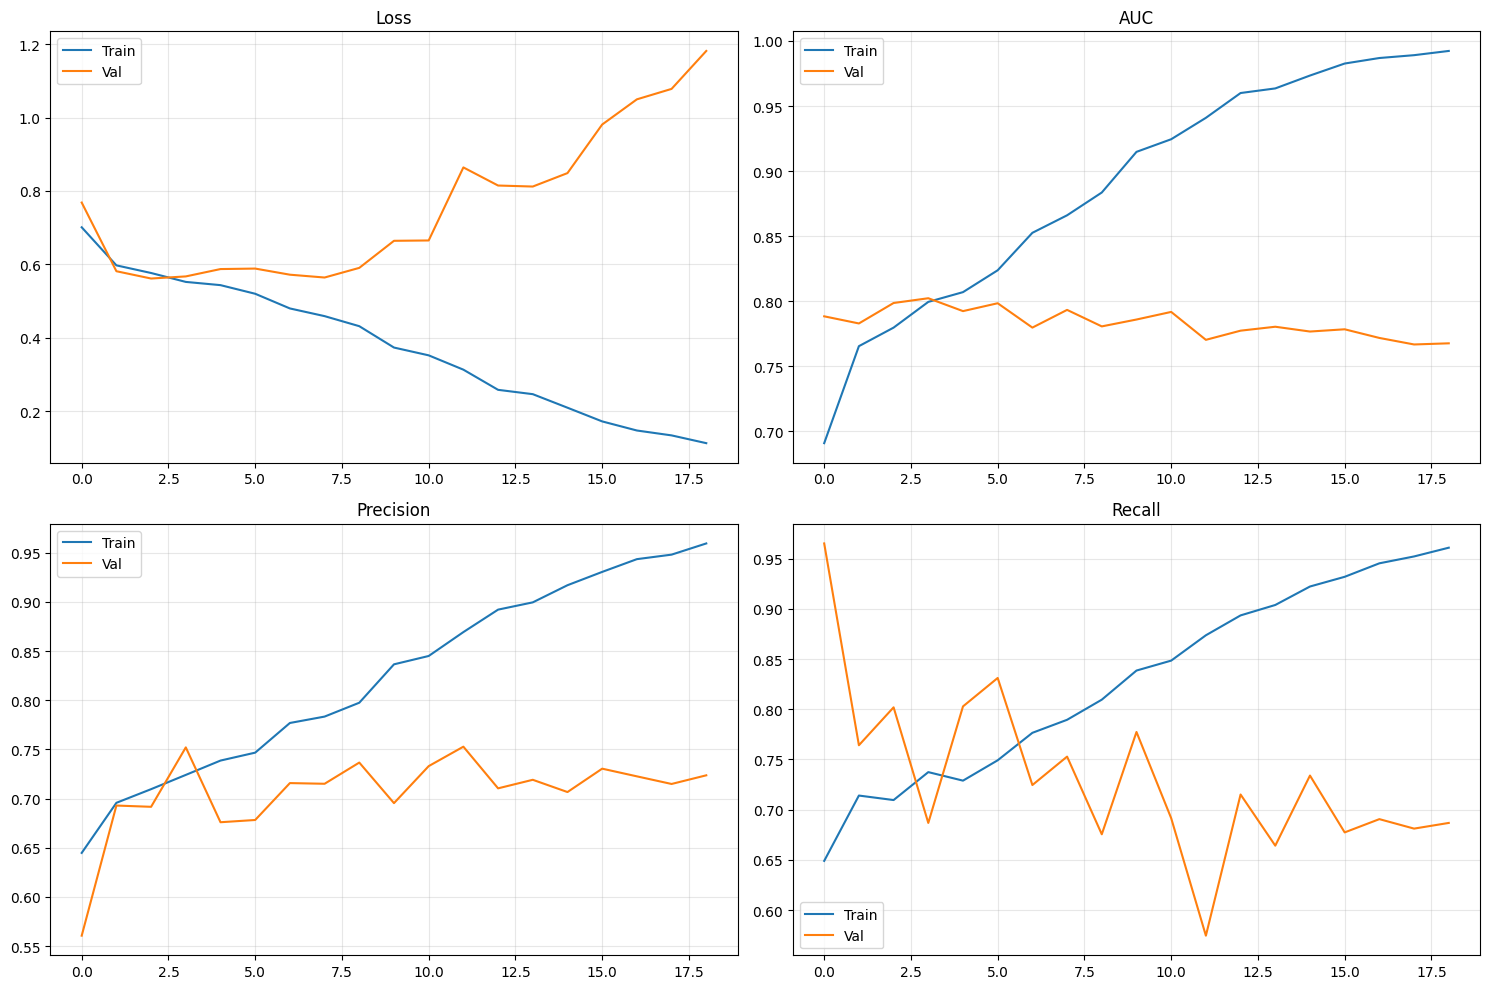

In [15]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train')
axes[0, 0].plot(history.history['val_loss'], label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train')
axes[0, 1].plot(history.history['val_auc'], label='Val')
axes[0, 1].set_title('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train')
axes[1, 0].plot(history.history['val_precision'], label='Val')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train')
axes[1, 1].plot(history.history['val_recall'], label='Val')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./output/hybrid_training_history.png', dpi=300)
plt.show()

In [16]:
# ============================================================================
# RESULTS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAINING RESULTS")
print("="*80)
print(f"Best Val AUC: {max(history.history['val_auc']):.4f}")
print(f"Best Val Accuracy: {max(history.history['val_binary_accuracy']):.4f}")
print(f"Final Val AUC: {history.history['val_auc'][-1]:.4f}")
print("="*80)


TRAINING RESULTS
Best Val AUC: 0.8023
Best Val Accuracy: 0.7303
Final Val AUC: 0.7676


In [18]:
# ============================================================================
# MODEL PERFORMANCE SUMMARY: F1, PRECISION, RECALL, SENSITIVITY, SPECIFICITY
# ============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)

# Get true labels
y_true = val_df['binary_label'].values

# Get predictions
print("Generating predictions on validation set...")
y_pred_prob = model.predict(val_dataset, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Compute metrics
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)  # Sensitivity = Recall
f1 = f1_score(y_true, y_pred, zero_division=0)

# Compute specificity
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'Metric':<15} {'Score':>10}")
print("-" * 26)
print(f"{'Precision':<15} {precision:>10.4f}")
print(f"{'Recall':<15} {recall:>10.4f}")
print(f"{'Sensitivity':<15} {recall:>10.4f}")  # Sensitivity = Recall
print(f"{'Specificity':<15} {specificity:>10.4f}")
print(f"{'F1 Score':<15} {f1:>10.4f}")

# Optional: Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumothorax'], zero_division=0))

print("="*80)


MODEL PERFORMANCE SUMMARY
Generating predictions on validation set...
67/67 [==============================] - 7s 89ms/step

Metric               Score
--------------------------
Precision           0.7521
Recall              0.6868
Sensitivity         0.6868
Specificity         0.7738
F1 Score            0.7179

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.71      0.77      0.74      1061
Pneumothorax       0.75      0.69      0.72      1060

    accuracy                           0.73      2121
   macro avg       0.73      0.73      0.73      2121
weighted avg       0.73      0.73      0.73      2121

